In [9]:
# Data handling
import pandas as pd
import numpy as np

# RDKit for molecular descriptors
from rdkit import Chem
from rdkit.Chem import Descriptors

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Feature importance visualization
import matplotlib.pyplot as plt


In [11]:
train_df = pd.read_csv("../data/qsar_ready_final_ACHE.csv")
print(train_df.columns)  # should include: ID, SMILES, pIC50, Activity


Index(['ID', 'SMILES', 'pIC50', 'can_smiles', 'Activity'], dtype='str')


In [12]:
threshold = 6.0  # define your activity threshold
train_df['Activity_bin'] = train_df['pIC50'].apply(lambda x: 1 if x >= threshold else 0)


In [13]:
train_df['mol'] = train_df['SMILES'].apply(Chem.MolFromSmiles)

# Generic 2D descriptors (Lipinski's rule type)
def calc_descriptors(mol):
    if mol is None:
        return [None]*6
    return [
        Descriptors.MolWt(mol), 
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumRotatableBonds(mol)
    ]

desc_list = train_df['mol'].apply(calc_descriptors)
desc_df = pd.DataFrame(desc_list.tolist(), columns=['MolWt','LogP','HDonors','HAcceptors','TPSA','RotBonds'])
train_qsar_df = pd.concat([train_df, desc_df], axis=1).dropna()
print(desc_list)


0       [243.34999999999997, 2.773500000000001, 0, 2, ...
1       [271.40400000000005, 3.5537000000000027, 0, 2,...
2            [208.28099999999998, 2.11702, 0, 2, 26.3, 2]
3       [405.54200000000026, 4.509200000000004, 0, 5, ...
4       [236.26699999999997, 2.0873, 0, 4, 44.76000000...
                              ...                        
6711    [250.34199999999998, 2.7597000000000014, 0, 3,...
6712    [250.34199999999998, 2.7597000000000014, 0, 3,...
6713         [287.35900000000004, 1.8503, 1, 4, 41.93, 1]
6714    [212.25199999999998, 3.033120000000001, 1, 2, ...
6715                   [194.194, -1.0293, 0, 3, 61.82, 0]
Name: mol, Length: 6716, dtype: object


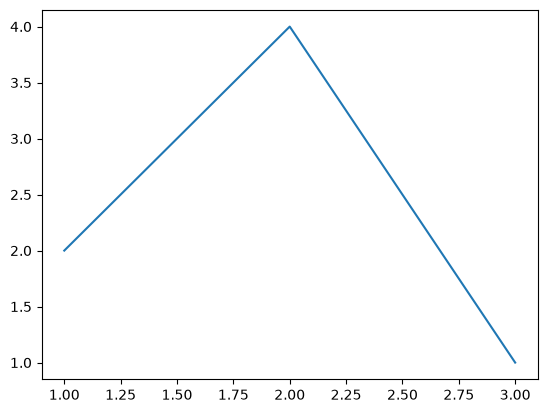

Top descriptors selected: Index(['LogP', 'MolWt', 'TPSA', 'RotBonds', 'HAcceptors', 'HDonors'], dtype='str')


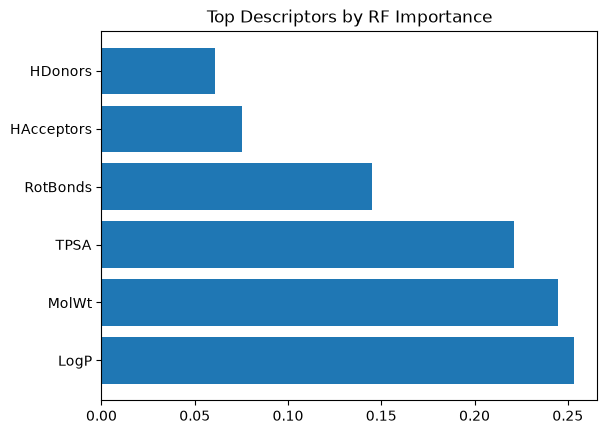

In [14]:
import os
import matplotlib.pyplot as plt

# create ACHE folder if it doesn't exist
os.makedirs("ACHE", exist_ok=True)

# plot
plt.plot([1, 2, 3], [2, 4, 1])

# save in ACHE folder
plt.savefig("ACHE/my_figure.png", dpi=300, bbox_inches='tight')
plt.show()



# Features & target
X_all = train_qsar_df[['MolWt','LogP','HDonors','HAcceptors','TPSA','RotBonds']]
y = train_qsar_df['Activity_bin']

# Fit a Random Forest to find feature importance
rf_temp = RandomForestClassifier(n_estimators=500, random_state=42)
rf_temp.fit(X_all, y)

importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1]  # descending order
top_features = X_all.columns[indices][:10]  # top 10 (or all if <10)

print("Top descriptors selected:", top_features)

# Optional: visualize
plt.barh(range(len(top_features)), importances[indices][:len(top_features)], align='center')
plt.yticks(range(len(top_features)), top_features)
plt.title("Top Descriptors by RF Importance")
plt.show()


In [16]:
X = X_all[top_features]  # only top descriptors
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [17]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42)
}

best_model_name = None
best_accuracy = 0
best_model = None

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    print(f"\n--- {name} ---")
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    print("Classification Report:\n", classification_report(y_val, y_pred))
    accuracy = np.mean(y_pred == y_val)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name
        best_model = model

print(f"\n✅ Best Model: {best_model_name} with accuracy {best_accuracy}")



--- Random Forest ---
Confusion Matrix:
 [[438 155]
 [138 613]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75       593
           1       0.80      0.82      0.81       751

    accuracy                           0.78      1344
   macro avg       0.78      0.78      0.78      1344
weighted avg       0.78      0.78      0.78      1344


--- Logistic Regression ---
Confusion Matrix:
 [[185 408]
 [162 589]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.31      0.39       593
           1       0.59      0.78      0.67       751

    accuracy                           0.58      1344
   macro avg       0.56      0.55      0.53      1344
weighted avg       0.57      0.58      0.55      1344


--- Gradient Boosting ---
Confusion Matrix:
 [[370 223]
 [156 595]]
Classification Report:
               precision    recall  f1-score   support

           0  

/home/mayank/miniconda3/envs/bioinfo/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



--- SVM ---
Confusion Matrix:
 [[287 306]
 [152 599]]
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.48      0.56       593
           1       0.66      0.80      0.72       751

    accuracy                           0.66      1344
   macro avg       0.66      0.64      0.64      1344
weighted avg       0.66      0.66      0.65      1344


--- MLP ---
Confusion Matrix:
 [[392 201]
 [122 629]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.66      0.71       593
           1       0.76      0.84      0.80       751

    accuracy                           0.76      1344
   macro avg       0.76      0.75      0.75      1344
weighted avg       0.76      0.76      0.76      1344


✅ Best Model: Random Forest with accuracy 0.7819940476190477


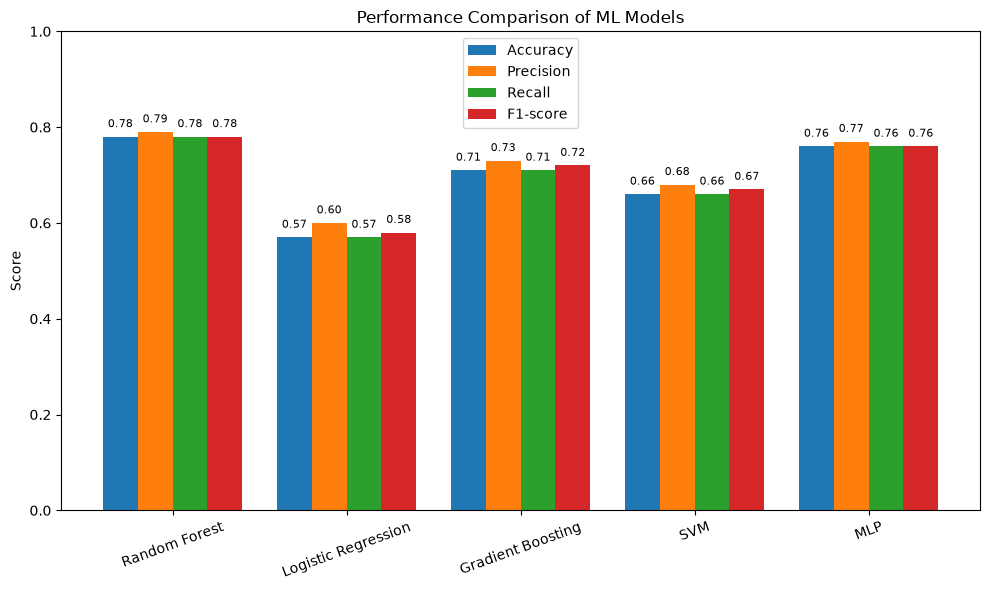

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ["Random Forest", "Logistic Regression", "Gradient Boosting", "SVM", "MLP"]

# Metrics (example values from your Table — replace with exact ones)
accuracy  = [0.78, 0.57, 0.71, 0.66, 0.76]
precision = [0.79, 0.60, 0.73, 0.68, 0.77]
recall    = [0.78, 0.57, 0.71, 0.66, 0.76]
f1_score  = [0.78, 0.58, 0.72, 0.67, 0.76]

# Combine
metrics = [accuracy, precision, recall, f1_score]
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]

# Bar settings
x = np.arange(len(models))  # positions
width = 0.2                 # width of each bar

plt.figure(figsize=(10,6))

# Plot bars for each metric
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, metric, width, label=metric_names[i])

# Formatting
plt.xticks(x + width*1.5, models, rotation=20)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Performance Comparison of ML Models")
plt.legend()

# Add values on bars
for i, metric in enumerate(metrics):
    for j, val in enumerate(metric):
        plt.text(x[j] + i*width, val + 0.02, f"{val:.2f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()



In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=kf)
print("5-fold CV Accuracy:", cv_scores.mean())


5-fold CV Accuracy: 0.768055606080291


In [21]:
test_df = pd.read_csv("Test_Data_UTF8.csv")
test_df['mol'] = test_df['can_smiles'].apply(Chem.MolFromSmiles)

desc_list_test = test_df['mol'].apply(calc_descriptors)
desc_df_test = pd.DataFrame(desc_list_test.tolist(), columns=['MolWt','LogP','HDonors','HAcceptors','TPSA','RotBonds'])

test_qsar_df = pd.concat([test_df, desc_df_test], axis=1).dropna()
X_test_final = test_qsar_df[top_features]
X_test_scaled = scaler.transform(X_test_final)


FileNotFoundError: [Errno 2] No such file or directory: 'Test_Data_UTF8.csv'

In [22]:
y_pred_test = best_model.predict(X_test_scaled)
y_prob_test = best_model.predict_proba(X_test_scaled)[:,1]

test_qsar_df['Predicted_Activity'] = y_pred_test
test_qsar_df['Probability_Active'] = y_prob_test

active_compounds = test_qsar_df[test_qsar_df['Predicted_Activity']==1]

print(active_compounds[['ID','Name','can_smiles','Predicted_Activity','Probability_Active']])


NameError: name 'X_test_scaled' is not defined

In [12]:
# Number of predicted active compounds
print("Number of predicted active compounds:", active_compounds.shape[0])

# Save results
test_qsar_df.to_csv("Test_Predictions_ExternalValidation.csv", index=False)
active_compounds.to_csv("Test_ActiveCompounds.csv", index=False)


Number of predicted active compounds: 22


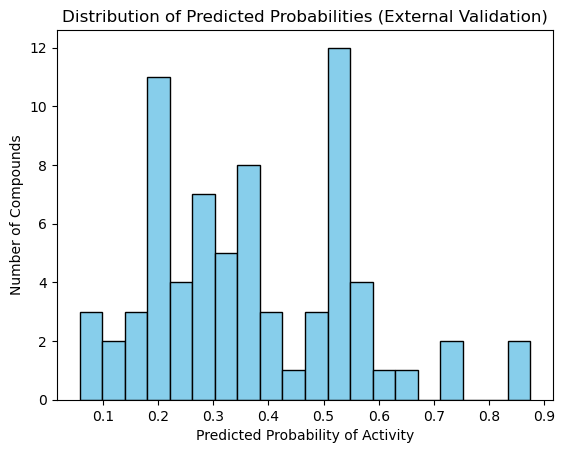

In [13]:
import matplotlib.pyplot as plt

plt.hist(test_qsar_df['Probability_Active'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Predicted Probability of Activity')
plt.ylabel('Number of Compounds')
plt.title('Distribution of Predicted Probabilities (External Validation)')
plt.show()


In [23]:
import pickle
import json
from pathlib import Path

save_dir = Path("../models/Alzheimer/AChE")
save_dir.mkdir(parents=True, exist_ok=True)

# Save trained model
with open(save_dir / "model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open(save_dir / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save selected feature names
with open(save_dir / "top_features.pkl", "wb") as f:
    pickle.dump(list(top_features), f)

# Create configuration
config = {
    "target": "AChE",
    "best_model": best_model_name,
    "validation_accuracy": round(best_accuracy, 4),
    "cross_validation_accuracy": round(float(cv_scores.mean()), 4),
    "activity_threshold": threshold,
    "descriptors": list(top_features)
}

# Save configuration
with open(save_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

print("===================================")
print("CompoundAI model exported successfully!")
print("===================================")
print(f"Model folder: {save_dir}")
print("Files created:")
print("  ✓ model.pkl")
print("  ✓ scaler.pkl")
print("  ✓ top_features.pkl")
print("  ✓ config.json")
print("===================================")

CompoundAI model exported successfully!
Model folder: ../models/Alzheimer/AChE
Files created:
  ✓ model.pkl
  ✓ scaler.pkl
  ✓ top_features.pkl
  ✓ config.json
